In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_excel('/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv.xlsx')
data.head()

,Transaction_id,User_id,Age,Gender,Daily_screen_time_hours,Social_media_hours,Gaming_hours,Work_study_hours,Sleep_hours,Notifications_per_day,App_opens_per_day,Weekend_screen_time,Stress_level,Academic_work_impact,Addiction_level,Addicted_label
0,Txn00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,Txn00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,Txn00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,Txn00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,Txn00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
print(data.shape)
print(data.info())
print(data.isnull().sum())
print(data.duplicated().sum())




(7500, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction_id           7500 non-null   object 
 1   User_id                  7500 non-null   object 
 2   Age                      7500 non-null   int64  
 3   Gender                   7500 non-null   object 
 4   Daily_screen_time_hours  7500 non-null   float64
 5   Social_media_hours       7500 non-null   float64
 6   Gaming_hours             7500 non-null   float64
 7   Work_study_hours         7500 non-null   float64
 8   Sleep_hours              7500 non-null   float64
 9   Notifications_per_day    7500 non-null   int64  
 10  App_opens_per_day        7500 non-null   int64  
 11  Weekend_screen_time      7500 non-null   float64
 12  Stress_level             7500 non-null   object 
 13  Academic_work_impact     7500 non-null   object 
 14  Addiction_lev

In [ ]:
mode_addiction_level = data['Addiction_level'].mode()[0]
data['Addiction_level'].fillna(mode_addiction_level, inplace=True)

/tmp/ipykernel_6193/626615841.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Addiction_level'].fillna(mode_addiction_level, inplace=True)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction_id           7500 non-null   object 
 1   User_id                  7500 non-null   object 
 2   Age                      7500 non-null   int64  
 3   Gender                   7500 non-null   object 
 4   Daily_screen_time_hours  7500 non-null   float64
 5   Social_media_hours       7500 non-null   float64
 6   Gaming_hours             7500 non-null   float64
 7   Work_study_hours         7500 non-null   float64
 8   Sleep_hours              7500 non-null   float64
 9   Notifications_per_day    7500 non-null   int64  
 10  App_opens_per_day        7500 non-null   int64  
 11  Weekend_screen_time      7500 non-null   float64
 12  Stress_level             7500 non-null   object 
 13  Academic_work_impact     7500 non-null   object 
 14  Addiction_level         

###EDA


In [ ]:
print("Mean - " ,data.mean(numeric_only=True))
print("Median - ", data.median(numeric_only=True))
print("Count - ", data.count())
print("Min - ", data.min())
print("Max - ", data.max())

Mean -  Age                         26.568800
Daily_screen_time_hours      7.499912
Social_media_hours           3.273484
Gaming_hours                 2.014183
Work_study_hours             3.242420
Sleep_hours                  6.737561
Notifications_per_day      134.257333
App_opens_per_day           97.832400
Weekend_screen_time          9.243827
Addicted_label               0.707733
dtype: float64
Median -  Age                         27.000
Daily_screen_time_hours      7.525
Social_media_hours           3.270
Gaming_hours                 2.040
Work_study_hours             3.230
Sleep_hours                  6.720
Notifications_per_day      134.000
App_opens_per_day           98.000
Weekend_screen_time          9.260
Addicted_label               1.000
dtype: float64
Count -  Transaction_id             7500
User_id                    7500
Age                        7500
Gender                     7500
Daily_screen_time_hours    7500
Social_media_hours         7500
Gaming_hours         

###Scatter Plot (For Trends)

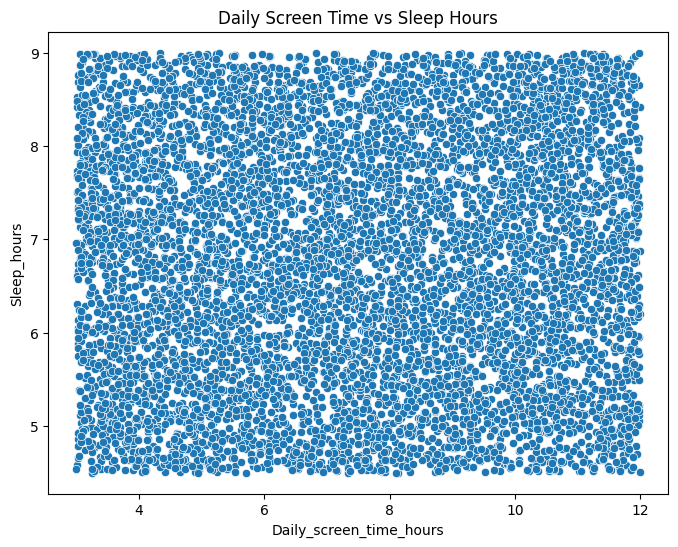

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Daily_screen_time_hours", y="Sleep_hours", data=data)
plt.title("Daily Screen Time vs Sleep Hours")
plt.show()

###Heatmap (For Correlation)

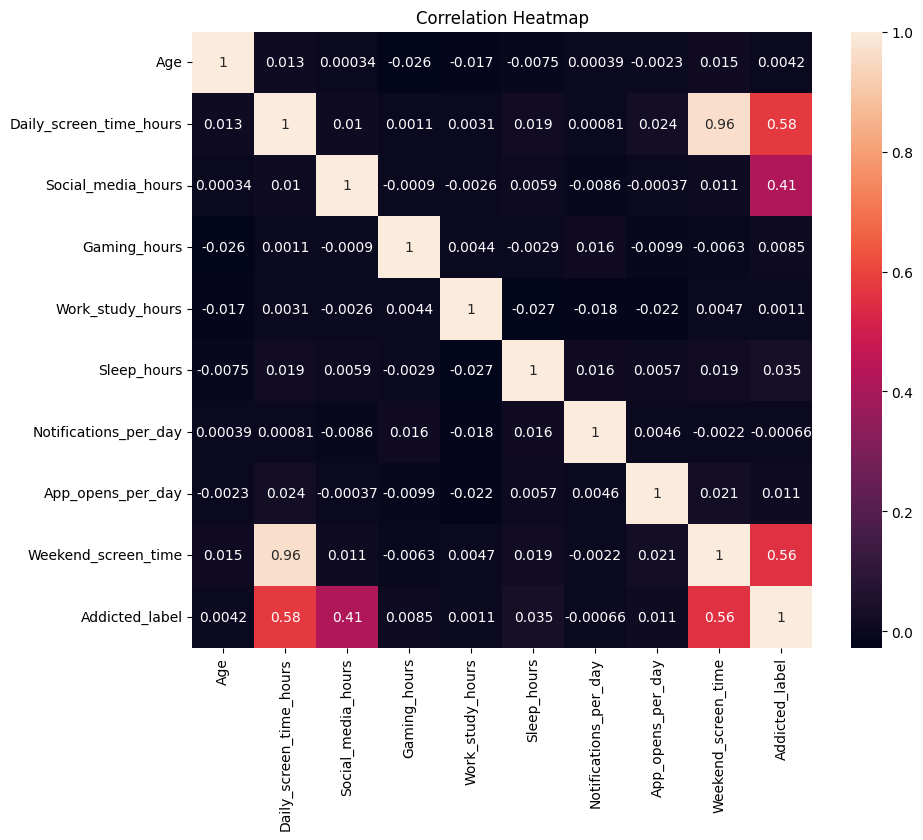

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.drop(columns=["Transaction_id"]).corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

###Boxplot (For Outliers)


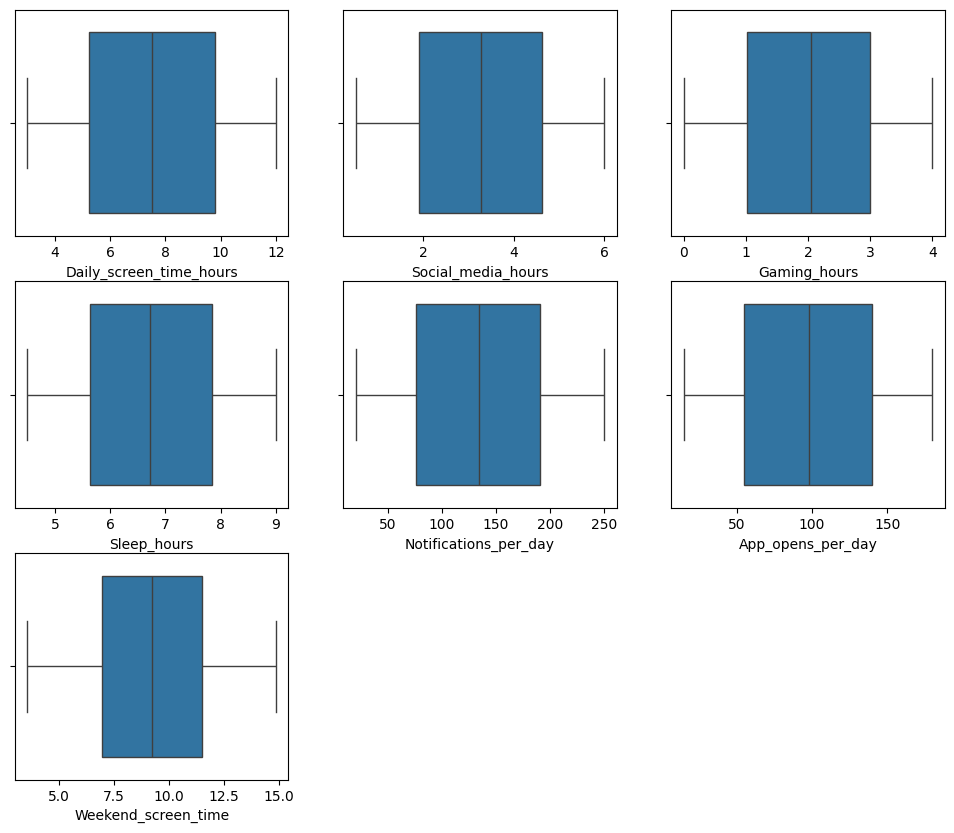

In [ ]:
cols = [
    "Daily_screen_time_hours",
    "Social_media_hours",
    "Gaming_hours",
    "Sleep_hours",
    "Notifications_per_day",
    "App_opens_per_day",
    "Weekend_screen_time"]
def boxplots(cols,j):
   plt.subplot(3,3,j)
   sns.boxplot(x=cols,data=data)
plt.figure(figsize=(12,10))
for i in range (len(cols)):
  boxplots(cols[i],i+1)

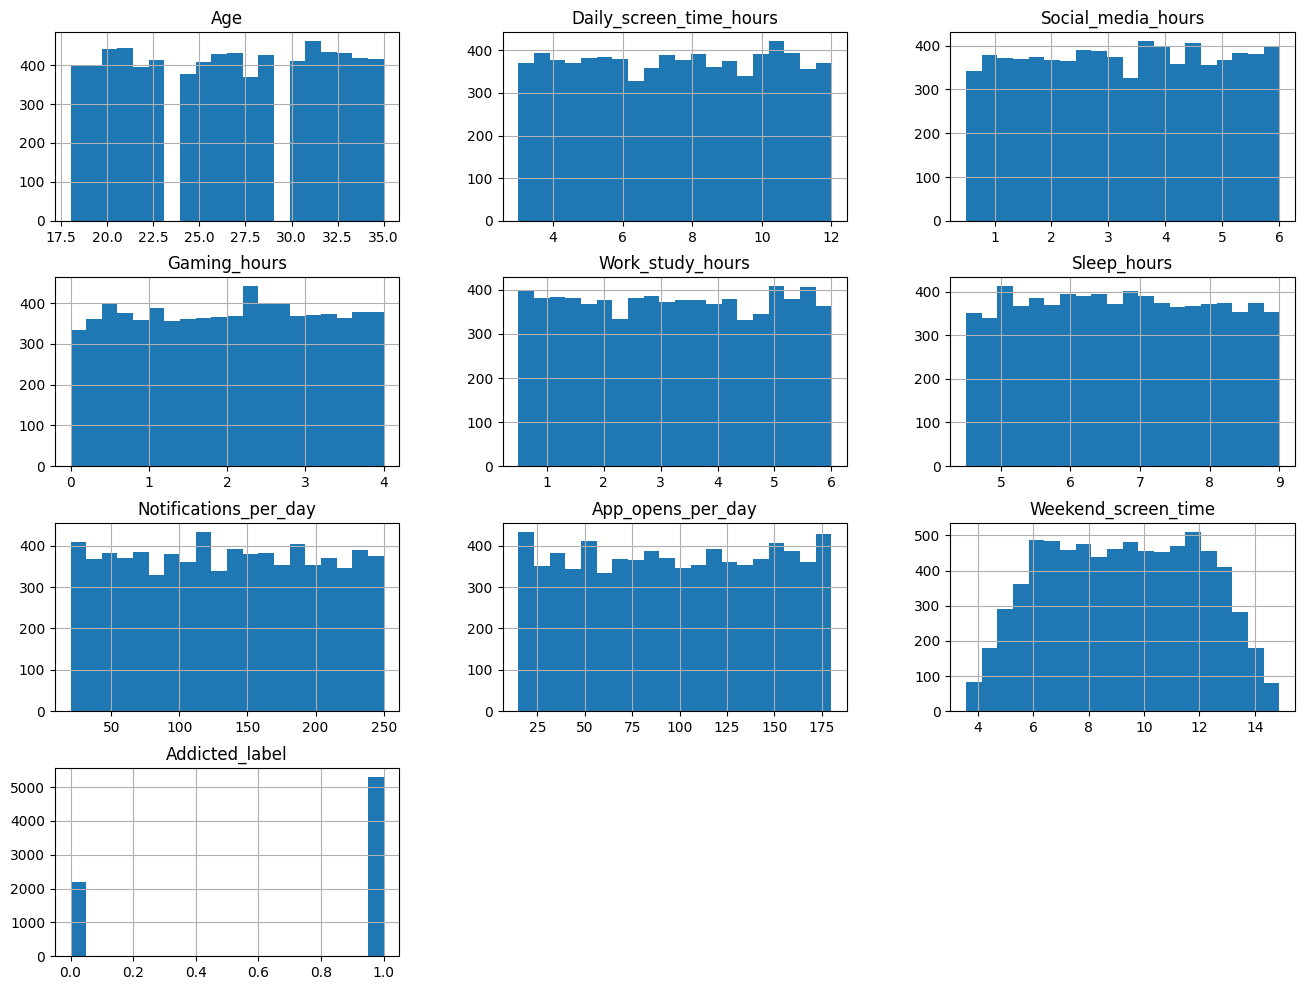

In [ ]:
distribution_data = data.drop(columns=["Transaction_id", "User_id"])
distribution_data.hist(figsize=(16, 12), bins=20)
plt.show()